# Lab 4: Non-negative Matrix Factorization

Welcome to the advanced Machine Learning Course.

The objective of this lab session is to code a few regression algorithms and to apply them to synthetic and real datasets.

Please put **"ML - MDS - TD4"** in the mail subject or I might lose your work (which means 0) and send it to pierre.houdouin@centralesupelec.fr

Please label your notebook **"L4_familyname1_familyname2.ipynb"** or I might lose your work (which means 0).

We begin with the standard imports:

In [2]:
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns
from sklearn.utils       import check_random_state
from sklearn.datasets    import fetch_olivetti_faces

%matplotlib inline
sns.set_context('poster')
sns.set_color_codes()
plot_kwds        = {'alpha' : 0.25, 's' : 80, 'linewidths':0}

dataset          = fetch_olivetti_faces(shuffle=True)
faces            = dataset.data.T # on représente chaque image par une colonne, en accord avec le cours
faces[3523][338] = 1e-2 # l'un des éléments de faces est nul, ce qui bloque la divergence de KL

## NMF

Loss (Regularized Froebnius): $\mathcal{L}(W, H) = \frac{1}{2}\|X-W H\|_{F}^{2}+ \color{red}{\frac{\mu}{2}\|H\|_{F}^{2}+\lambda\|H\|_{1}+\frac{\nu}{2}\|W\|_{F}^{2}}$

Algorithm (multiplicative updates from [Lee and Seung, 1999]: 

\begin{array}{c}
W \leftarrow W \circ \frac{X H^{\top}}{W (H H^{\top} + {\color{red} \nu I_r})} \\
H \leftarrow H \circ \frac{W^{\top} X - {\color{red} \lambda 1_{r \times n}}}{(W^{\top} W + {\color{red} \mu I_r})H}
\end{array}

Fill in the following NMF class:

In [3]:
class MYNMF:
    """Class for logistic regression:

    Attributes:
    -----------                                                Default value
    n_components_ : integer,  unknown dimension of W and H   | 20
    max_iter_     : integer,  maximum number of iterations   | 60
    epsilon_      : float,    epsilon coefficient            | 1e-4
    loss_         : str,      {"Frobenius", "KL"}            | Frobenius
    D_            : np.array, W Matrix factor                | None
    S_            : np.array, H Matrix factor                | None
    D_history     : list,     W Matrix history               | []
    S_history     : list,     H Matrix history               | []
    loss_history  : list,     history of loss                | []
    random_state  : int,      for the random initialization  | 42
    """

    def __init__(
        self,
        n_components=20,
        max_iter=200,
        epsilon=1e-5,
        loss="Frobenius",
        random_state=42,
    ):
        self.n_components_ = n_components
        self.max_iter_ = max_iter
        self.epsilon_ = epsilon
        self.loss_ = loss
        self.D_ = None
        self.S_ = None
        self.D_history = []
        self.S_history = []
        self.loss_history = []
        self.random_state = random_state
        self.components_ = None  # shape (r, p)

    def fit_transform(self, data, mu=5e-3, nu=5e-3, lambd=1e-3):
        """Find the factor matrices D and S for matrix factorization of data

        Parameters:
        -----------                                 Default value
        data  : (p, n) np.arrayData, matrix       |
        mu    : float, regularization parameter   | 5e-3
        lambd : float, regularization parameter   | 1e-3
        nu    : float, regularization parameter   | 5e-3

        Returns:
        -----
        embedding: (p, r) np.array
                    Embedding matrix
        """

        # Multiplicative update rules and loss functions
        def step_Frobenius(D, S, X, mu, nu, lambd):
            D_new = D * (X @ S.T) / (D @ (S @ S.T + nu * np.eye(S.shape[0])))
            S_new = (
                S
                * ((D_new.T @ X) - lambd)
                / ((D_new.T @ D_new + mu * np.eye(D_new.shape[1])) @ S)
            )

            D_new = np.maximum(D_new, 1e-10)
            S_new = np.maximum(S_new, 1e-10)
            return D_new, S_new

        def step_KL(D, S, X):
            X_over_DS = X / (D @ S)
            D_new = D * (X_over_DS @ S.T) / (np.sum(S, axis=1, keepdims=True).T)
            S_new = S * (D_new.T @ X_over_DS) / (np.sum(D_new, axis=0, keepdims=True).T)

            D_new = np.maximum(D_new, 1e-10)
            S_new = np.maximum(S_new, 1e-10)
            return D_new, S_new

        def loss_Frobenius(D, S, X, mu, nu, lambd):
            return (
                0.5 * np.linalg.norm(X - D @ S, "fro") ** 2
                + (mu / 2) * np.linalg.norm(S, "fro") ** 2
                + (nu / 2) * np.linalg.norm(D, "fro") ** 2
                + lambd * np.sum(S)
            )

        def loss_KL(D, S, X):
            DS = D @ S
            return np.sum(X * np.log(X / DS) - X + DS)

        # Choose the right step and loss functions
        if self.loss_ == "Frobenius":
            step = lambda D, S, X: step_Frobenius(D, S, X, mu, nu, lambd)
            loss_func = lambda D, S, X: loss_Frobenius(D, S, X, mu, nu, lambd)
        elif self.loss_ == "KL":
            step = step_KL
            loss_func = loss_KL
        else:
            raise ValueError("loss must be 'Frobenius' or 'KL'")

        # Initialisation
        rng = check_random_state(self.random_state)
        n_features, n_samples = data.shape
        D = np.maximum(rng.rand(n_features, self.n_components_), 0)
        S = np.maximum(rng.rand(self.n_components_, n_samples), 0)
        self.D_history.append(D)
        self.S_history.append(S)
        self.loss_history.append(loss_func(D, S, data))

        # Iterations
        for i in range(self.max_iter_):
            print(f"Iteration {i+1}/{self.max_iter_}", end="\r")
            D, S = step(D, S, data)
            loss = loss_func(D, S, data)

            self.loss_history.append(loss)
            self.D_history.append(D.copy())
            self.S_history.append(S.copy())
            
            if abs(self.loss_history[-2] - self.loss_history[-1]) < self.epsilon_:
                break
        self.D_ = D
        self.S_ = S
        self.components_ = S.T
        return self.components_            

    def predict_label(self, X):
        """Predict labels for X : cluster hard-assignment

        Parameters:
        -----------
        X: (n, p) np.array, data matrix

        Returns:
        -----
        label assignment : (p, ) np.array, Its elements are the predicted classes, from 0 to r-1
        """
        proj = np.linalg.lstsq(self.D_, X, rcond=None)[0]  
        labels = np.argmax(proj, axis=0) 
        return labels


    def predict_proba(self, X):
        """Predict probabilities of different classes for X :  cluster soft-assignment

        Parameters:
        -----------
        X: (n, p) np.array
            New data matrix

        Returns:
        -----
        label_assignment : (n, r) np.array
                          Its elements are the probabilities for different classes
        """
        proj = np.linalg.lstsq(self.D_, X, rcond=None)[0]  
        proj = np.maximum(proj, 0)  
        labels = proj / (np.sum(proj, axis=0, keepdims=True))
        return labels.T

## Hyperparameter optimization

### Regularization parameter : mu

mu=0.00001, loss=4675.82138
mu=0.00010, loss=4675.97570
mu=0.00050, loss=4676.66075
mu=0.00100, loss=4677.51517
mu=0.00500, loss=4684.27606
mu=0.01000, loss=4692.54530
mu=0.05000, loss=4752.22704
mu=0.10000, loss=4813.75172


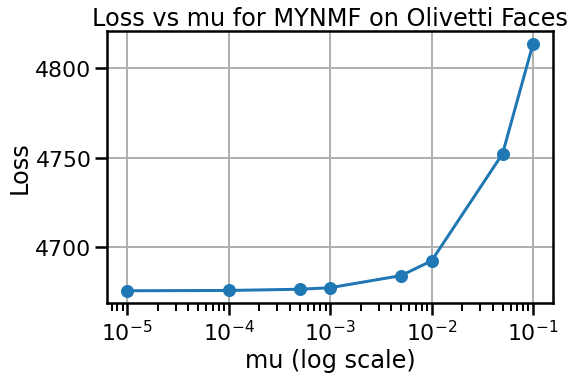


Best mu: 0.00001 with loss 4675.82138


In [4]:
mus = [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]
losses = []

for mu in mus:
    model = MYNMF()
    nu = 5e-3
    lambd = 1e-3
    model.fit_transform(faces, mu=mu, nu=nu, lambd=lambd)
    
    loss = model.loss_history[-1]
    
    losses.append(loss)
    print(f"mu={mu:.5f}, loss={loss:.5f}")

plt.figure(figsize=(8,5))
plt.plot(mus, losses, marker='o')
plt.xscale('log')
plt.xlabel("mu (log scale)")
plt.ylabel("Loss")
plt.title("Loss vs mu for MYNMF on Olivetti Faces")
plt.grid(True)
plt.show()

best_index = np.argmin(losses)
best_mu = mus[best_index]
print(f"\nBest mu: {best_mu:.5f} with loss {losses[best_index]:.5f}")

### Regularization parameter : nu

nu=0.00001, loss=4674.81430
nu=0.00010, loss=4674.83249
nu=0.00050, loss=4674.91332
nu=0.00100, loss=4675.01433
nu=0.00500, loss=4675.82138
nu=0.01000, loss=4676.82759
nu=0.05000, loss=4684.77488
nu=0.10000, loss=4694.45992


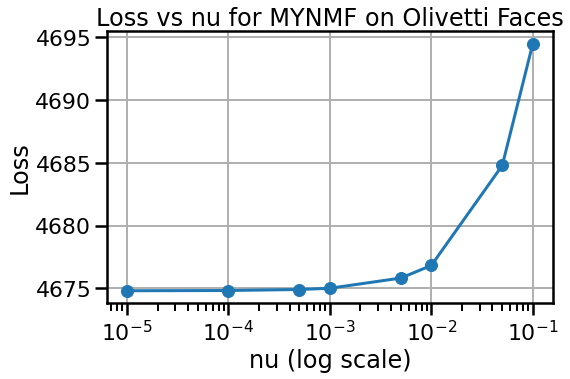


Best nu: 0.00001 with loss 4674.81430


In [5]:
# Grid search for nu
nus = [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]
losses = []

for nu in nus:
    model = MYNMF()
    mu = best_mu
    lambd = 1e-3
    model.fit_transform(faces, mu=mu, nu=nu, lambd=lambd)
    
    loss = model.loss_history[-1]
    
    losses.append(loss)
    print(f"nu={nu:.5f}, loss={loss:.5f}")

# Plot
plt.figure(figsize=(8,5))
plt.plot(nus, losses, marker='o')
plt.xscale('log')
plt.xlabel("nu (log scale)")
plt.ylabel("Loss")
plt.title("Loss vs nu for MYNMF on Olivetti Faces")
plt.grid(True)
plt.show()

best_index = np.argmin(losses)
best_nu = nus[best_index]
print(f"\nBest nu: {best_nu:.5f} with loss {losses[best_index]:.5f}")

### Regularization parameter : lambda

lambda=0.00001, loss=4670.79688
lambda=0.00010, loss=4671.16261
lambda=0.00050, loss=4672.78684
lambda=0.00100, loss=4674.81430
lambda=0.00500, loss=4690.92160
lambda=0.01000, loss=4710.77887
lambda=0.05000, loss=4859.34044
lambda=0.10000, loss=5022.57318


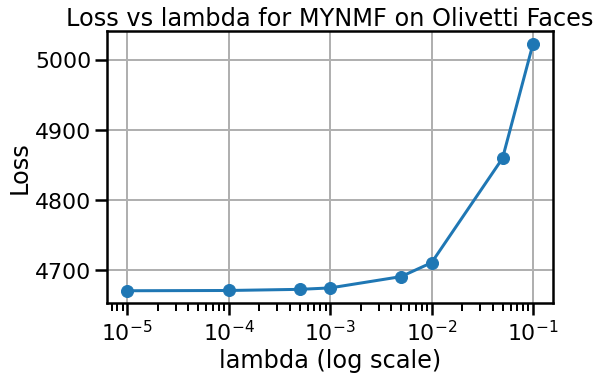


Best lambda: 0.00001 with loss 4670.79688


In [6]:
lambdas = [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]
losses = []

for lambd in lambdas:
    model = MYNMF()
    mu = best_mu
    nu = best_nu
    model.fit_transform(faces, mu=mu, nu=nu, lambd=lambd)
    
    loss = model.loss_history[-1]
    
    losses.append(loss)
    print(f"lambda={lambd:.5f}, loss={loss:.5f}")

plt.figure(figsize=(8,5))
plt.plot(lambdas, losses, marker='o')
plt.xscale('log')
plt.xlabel("lambda (log scale)")
plt.ylabel("Loss")
plt.title("Loss vs lambda for MYNMF on Olivetti Faces")
plt.grid(True)
plt.show()

best_index = np.argmin(losses)
best_lamb = lambdas[best_index]
print(f"\nBest lambda: {best_lamb:.5f} with loss {losses[best_index]:.5f}")

In [7]:
model = MYNMF()
model.fit_transform(faces, mu=best_mu, nu=best_nu, lambd=best_lamb)

loss = model.loss_history[-1]

print(f"Loss for best parameters: {loss:.5f}")

Loss for best parameters: 4670.79688


### Number of components

We are going to determine the **optimal number of components** for the factorization by plotting the final loss after 100 epochs for different number of components.
We expect an **elbow curve**, and we will choose the value at the elbow point. Indeed, the higher the number of components is, the more precise the atoms of the dictionary can be, and thus the more precise the reconstructed image will be.
We will find the optimal parameter both for Frobenius and Kullback-Leibler distances.

#### Case of Frobenius distance

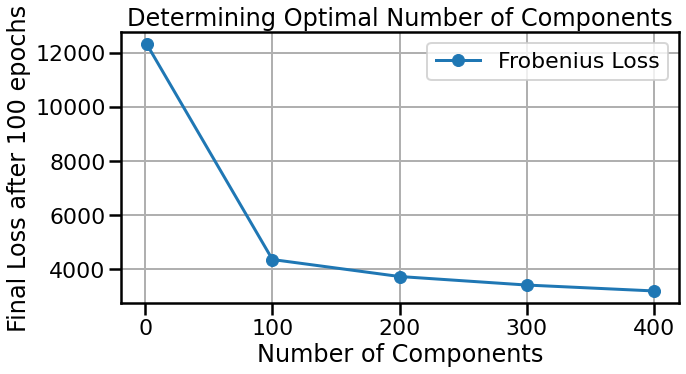

In [8]:
component_range = np.linspace(1, min(faces.shape[0], faces.shape[1]), 5, dtype=int)
frobenius_losses = []

for n_comp in component_range:
    model_fro = MYNMF(n_components=n_comp, max_iter=100, loss="Frobenius")
    model_fro.fit_transform(faces, mu=best_mu, nu=best_nu, lambd=best_lamb)
    frobenius_losses.append(model_fro.loss_history[-1])

plt.figure(figsize=(10, 5))
plt.plot(component_range, frobenius_losses, marker='o', label='Frobenius Loss')
plt.xlabel('Number of Components')
plt.ylabel('Final Loss after 100 epochs')
plt.title('Determining Optimal Number of Components')
plt.legend()
plt.grid(True)
plt.show()

#### Case of Kullback-Leibler divergence

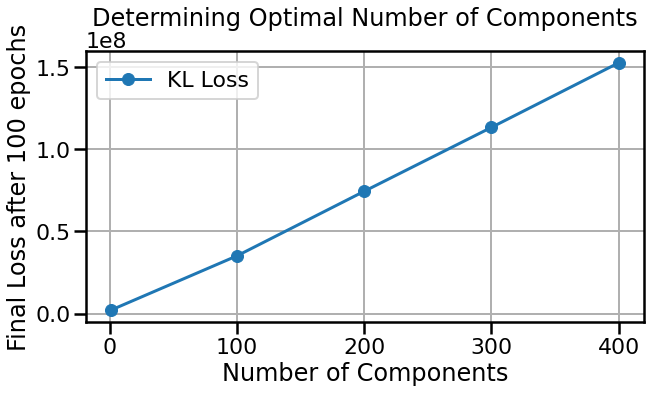

In [9]:
component_range = np.linspace(1, min(faces.shape[0], faces.shape[1]), 5, dtype=int)
kl_losses = []

for n_comp in component_range:
    model_kl = MYNMF(n_components=n_comp, max_iter=100, loss="KL")
    model_kl.fit_transform(faces)
    kl_losses.append(model_kl.loss_history[-1])

plt.figure(figsize=(10, 5))
plt.plot(component_range, kl_losses, marker='o', label='KL Loss')
plt.xlabel('Number of Components')
plt.ylabel('Final Loss after 100 epochs')
plt.title('Determining Optimal Number of Components')
plt.legend()
plt.grid(True)
plt.show()

## Comparison between the two distances

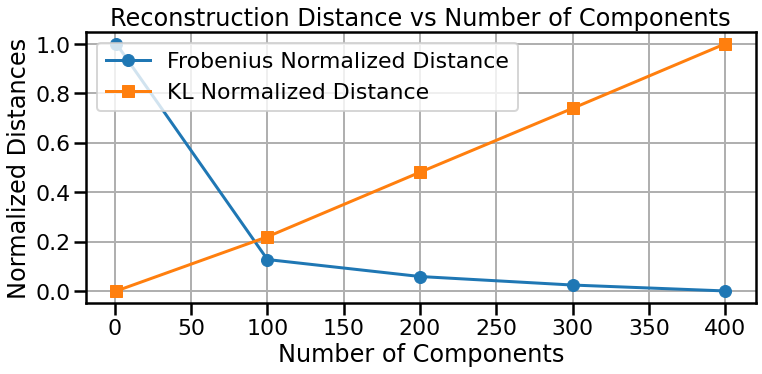

In [10]:
component_range = np.linspace(1, min(faces.shape[0], faces.shape[1]), 5, dtype=int)
frobenius_distances = []
kl_distances = []

for n_comp in component_range:
    model_fro = MYNMF(n_components=n_comp, max_iter=100, loss="Frobenius", random_state=42)
    S_fro = model_fro.fit_transform(faces,  mu=best_mu, nu=best_nu, lambd=best_lamb)
    frobenius_distances.append(model_fro.loss_history[-1])
    
    model_kl = MYNMF(n_components=n_comp, max_iter=100, loss="KL", random_state=42)
    S_kl = model_kl.fit_transform(faces)
    kl_distances.append(model_kl.loss_history[-1])

frobenius_distances = (frobenius_distances - np.min(frobenius_distances)) / (np.max(frobenius_distances) - np.min(frobenius_distances))
kl_distances = (kl_distances - np.min(kl_distances)) / (np.max(kl_distances) - np.min(kl_distances))
                                                                                      
plt.figure(figsize=(12, 5))

plt.plot(component_range, frobenius_distances, marker='o', label='Frobenius Normalized Distance')
plt.plot(component_range, kl_distances, marker='s', label='KL Normalized Distance')
plt.xlabel('Number of Components')
plt.ylabel('Normalized Distances')
plt.title('Reconstruction Distance vs Number of Components')
plt.legend()
plt.grid(True)
plt.show()

## Model training

### Training with Frobenius distance for different number of components

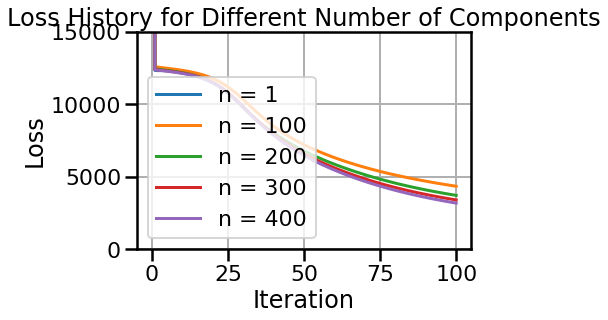

In [11]:
component_range = np.linspace(1, min(faces.shape[0], faces.shape[1]), 5, dtype=int)

for n_comp in component_range:
    model_fro = MYNMF(n_components=n_comp, max_iter=100, loss="Frobenius")
    model_fro.fit_transform(faces, mu=best_mu, nu=best_nu, lambd=best_lamb)
    plt.plot(model_fro.loss_history, label=f'n = {n_comp}')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss History for Different Number of Components')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=15000)
plt.show()

### Training with KL-divergence for different number of components

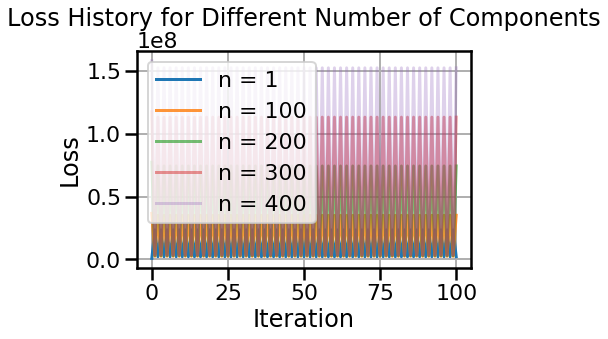

In [12]:
component_range = np.linspace(1, min(faces.shape[0], faces.shape[1]), 5, dtype=int)

for i,n_comp in enumerate(component_range):
    model_fro = MYNMF(n_components=n_comp, max_iter=100, loss="KL")
    model_fro.fit_transform(faces)
    alpha = 1 - 0.7 * i / (len(component_range) - 1)
    plt.plot(model_fro.loss_history, label=f'n = {n_comp}', alpha=alpha)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss History for Different Number of Components')
plt.legend()
plt.grid(True)
plt.show()

## Applications

### First application

For the first application you are going to analyse the following data to give an interpretation of the factorization:

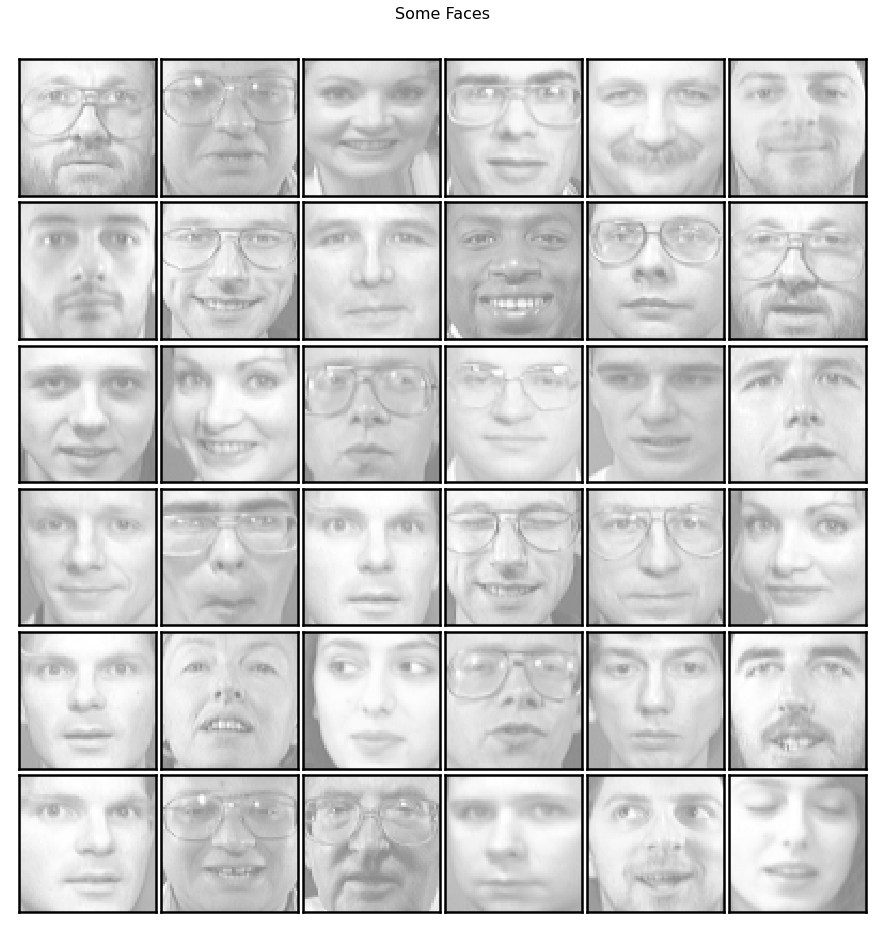

In [13]:
faces = faces.T  # n = 400 flattened images of p = 4096 = 64 x 64
image_shape = (64, 64)
n_samples, n_features = faces.shape

# global centering
faces_centered = faces - faces.mean(axis=0)

# local centering
faces_centered -= faces_centered.mean(axis=1).reshape(n_samples, -1)


def plot_gallery(images, image_shape, nrow, ncol, title="", cmap=plt.cm.gray):
    # fit the nb of images into a square
    n_images = len(images)
    nrows = nrow
    ncols = ncol

    # instantiate figure
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.0 * ncols, 2.26 * nrows))
    fig.suptitle(title, size=16)

    axes_for_display = axes.flatten()[:n_images]
    axes_to_blank = axes.flatten()[n_images:]

    for idx, comp in enumerate(images):
        ax = axes_for_display[idx]
        vmax = max(comp.max(), -comp.min())
        ax.imshow(
            comp.reshape(image_shape),
            cmap=cmap,
            interpolation="nearest",
            vmin=-vmax,
            vmax=vmax,
        )
        ax.set(xticks=(), yticks=())

    for ax in axes_to_blank:
        ax.axis("off")

    fig.tight_layout()
    fig.subplots_adjust(
        0.01, 0.05, 0.99, 0.93, 0.04, 0.0
    )  # insert space below the suptitle


plot_gallery(
    title="Some Faces", images=faces[:36], image_shape=image_shape, nrow=6, ncol=6
)

### Analysis of the number of components on the reconstruction

#### Reconstruction with Frobenius distance

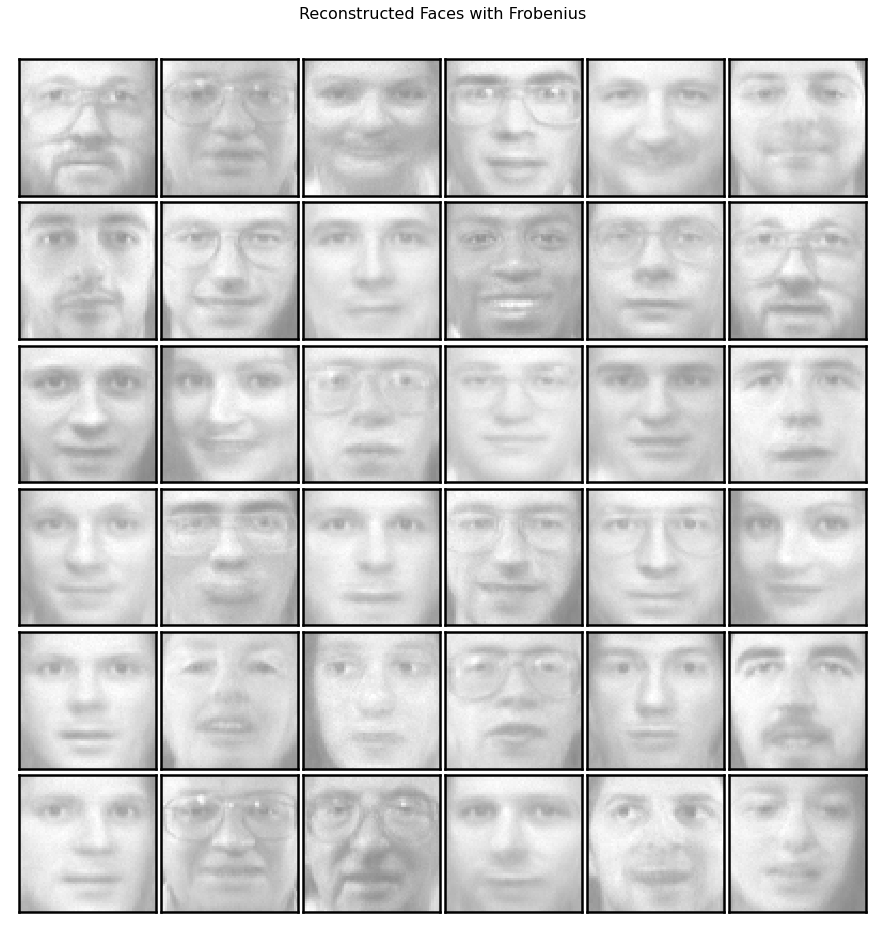

In [14]:
best_mu = 1e-5
best_nu = 1e-5
best_lamb = 1e-5

model = MYNMF(n_components=200, max_iter=200, loss="Frobenius")
model.fit_transform(faces, mu=best_mu, nu=best_nu, lambd=best_lamb)

reconstructed_faces = model.D_ @ model.S_

plot_gallery(title="Reconstructed Faces with Frobenius", images=reconstructed_faces[:36], image_shape=image_shape, nrow=6, ncol=6)

#### Reconstruction with Kullback-Leibler divergence

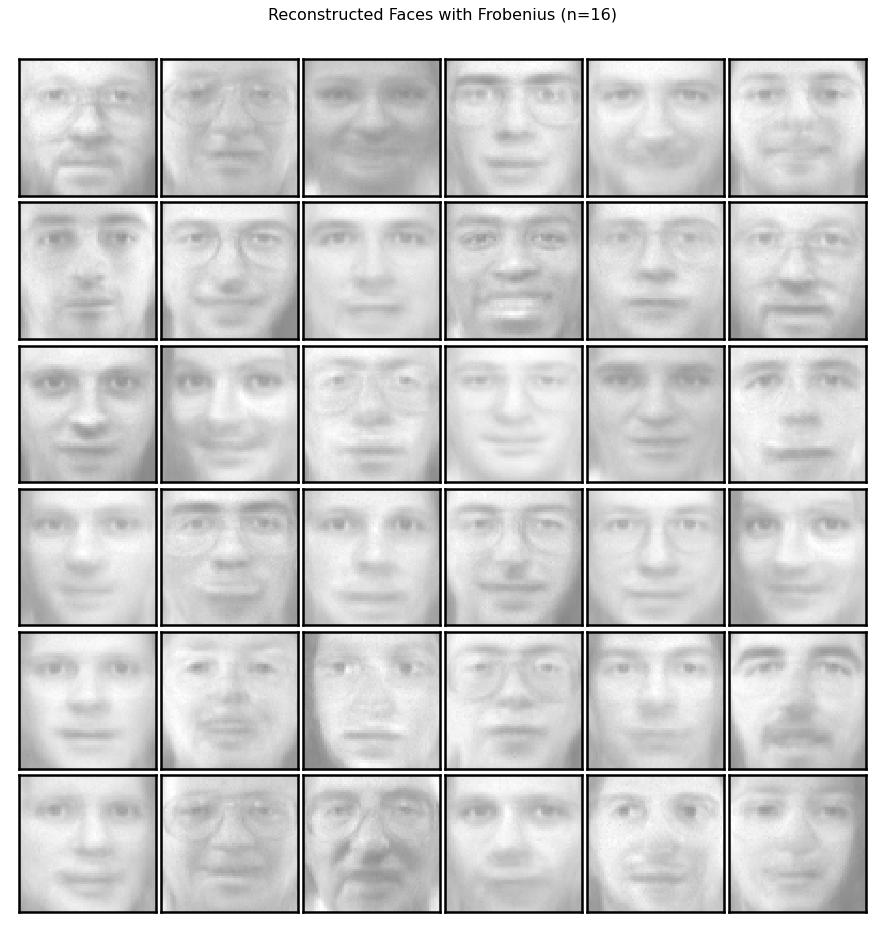

In [15]:
model = MYNMF(n_components=50, max_iter=200, loss="KL")
model.fit_transform(faces)

reconstructed_faces = model.D_ @ model.S_

plot_gallery(title="Reconstructed Faces with Frobenius (n=16)", images=reconstructed_faces[:36], image_shape=image_shape, nrow=6, ncol=6)

#### Comparison of the elements of the dictionary between the two distances

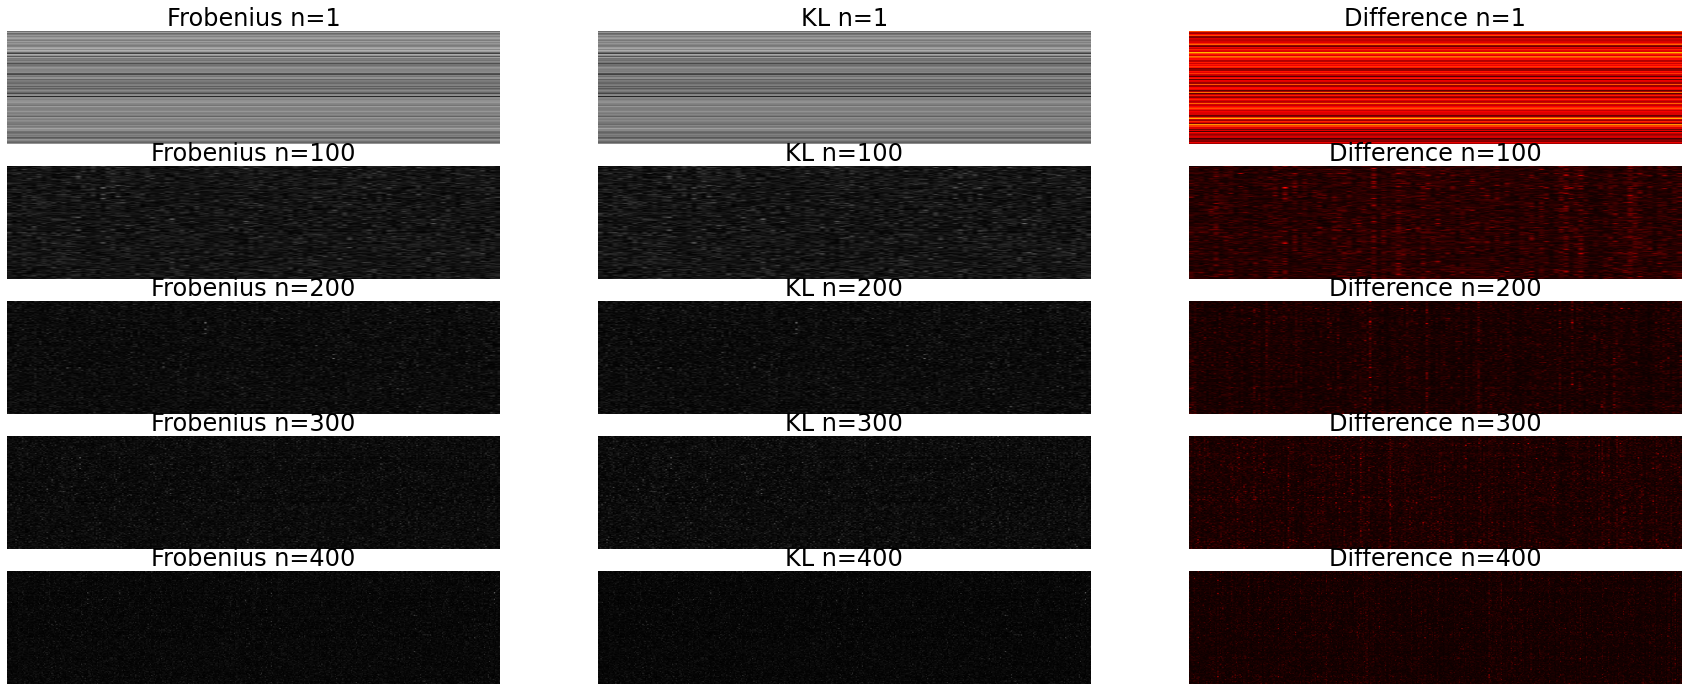

In [16]:
component_range = np.linspace(1, min(faces.shape[0], faces.shape[1]), 5, dtype=int)

fig, ax = plt.subplots(len(component_range), 3, figsize=(30, 12))

for i,n_comp in enumerate(component_range):
    model_fro = MYNMF(n_components=n_comp, max_iter=200, loss="Frobenius")
    model_fro.fit_transform(faces, mu=best_mu, nu=best_nu, lambd=best_lamb)
    ax[i,0].imshow(model_fro.D_, cmap=plt.cm.gray, aspect='auto')
    ax[i,0].set_title(f'Frobenius n={n_comp}')
    ax[i,0].axis('off')
    
    model_kl = MYNMF(n_components=n_comp, max_iter=200, loss="KL")
    model_kl.fit_transform(faces)
    ax[i,1].imshow(model_kl.D_, cmap=plt.cm.gray, aspect='auto')
    ax[i,1].set_title(f'KL n={n_comp}')
    ax[i,1].axis('off')
    
    difference = np.abs((model_fro.D_ / np.linalg.norm(model_fro.D_, axis=0)) - (model_kl.D_ / np.linalg.norm(model_kl.D_, axis=0)))
    ax[i,2].imshow(difference, cmap=plt.cm.hot, aspect='auto')
    ax[i,2].set_title(f'Difference n={n_comp}')
    ax[i,2].axis('off')

### Study of the clustering for the Frobenius distance with 30 components

Now, we are going to clusterise the images in r different classes. First, we start by normalizing the norm of the dictionary elements, so that the euclidian norm = 1, and we multiply the associated row in the S matrix to preserve the factorization DS = X. Then, we find the highest coefficient for each image, and we use the index of the maximum as clustering label.

Number of unique clusters: 30


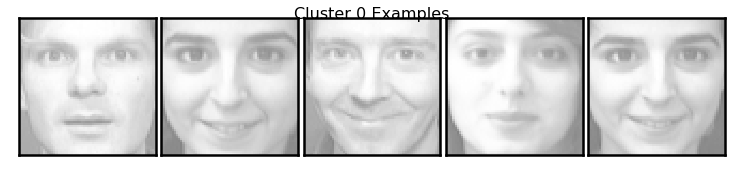

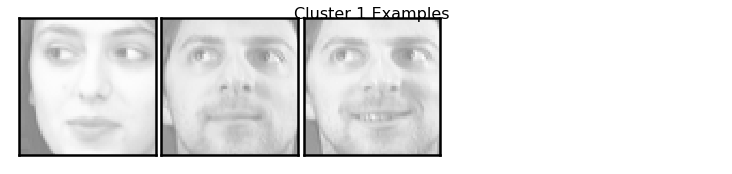

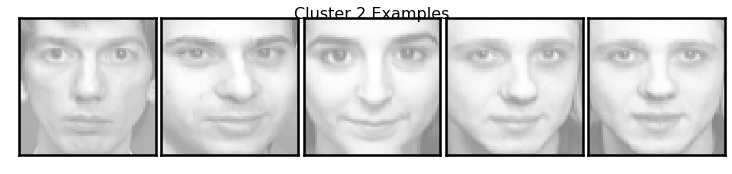

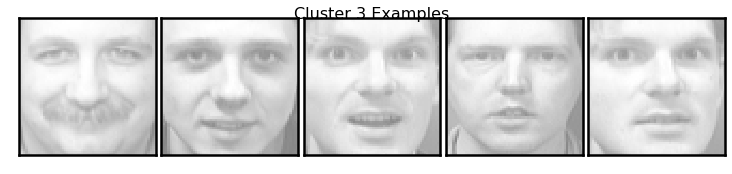

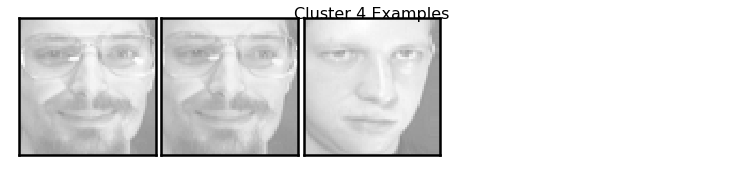

In [17]:
model = MYNMF(n_components=30, max_iter=200, loss="Frobenius", random_state=0)
model.fit_transform(faces.T, mu=best_mu, nu=best_nu, lambd=best_lamb)

D = model.D_
S = model.S_

# Normalize columns of D to unit norm and rescale S accordingly
norms = np.linalg.norm(D, axis=0) 
D_normed = D / norms
S_rescaled = S * norms[:, np.newaxis]  

# Update model attributes and predict labels
model.D_ = D_normed
model.S_ = S_rescaled

labels = model.predict_label(faces.T)

print("Number of unique clusters:", len(np.unique(labels)))

# Some example faces from some clusters
n_clusters_to_show = 5
n_examples_per_cluster = 5

for k in range(n_clusters_to_show):
    idxs = np.where(labels == k)[0][:n_examples_per_cluster]
    if len(idxs) == 0:
        continue
    faces_in_cluster = faces[idxs, :]  
    plot_gallery(faces_in_cluster, image_shape, nrow=1, ncol=n_examples_per_cluster, title=f"Cluster {k} Examples")

### Second application 

Import the 20newsgroups dataset (from sklearn.datasets import fetch_20newsgroups_vectorized) that contains a collection of ~18,000 newsgroup documents from 20 different newsgroups.

Model the topics present in a subsample with *scikit-learn's* NMF. Print the most common words of each topic. 

Discuss.

In [18]:
from sklearn.datasets import fetch_20newsgroups_vectorized
from sklearn.decomposition import NMF

# Load dataset
data = fetch_20newsgroups_vectorized()
X = data.data 
feature_names = data.feature_names  # list of words corresponding to columns

In [19]:
# Fit model for a given number of topics
n_topics = 10

nmf_model = NMF(n_components=n_topics, random_state=42, init='nndsvd', max_iter=200)
W = nmf_model.fit_transform(X) 
H = nmf_model.components_       

c:\Users\adoni\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\decomposition\_nmf.py:1692: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [20]:
# Print top words for each topic
n_top_words = 30

for topic_idx, topic in enumerate(H):
    top_word_indices = topic.argsort()[::-1][:n_top_words] 
    top_words = [feature_names[i] for i in top_word_indices]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: the, on, was, at, from, with, by, they, to, were, that, when, will, had, same, first, into, has, as, out, two, up, only, after, time, then, which, of, right, off
Topic 2: is, that, not, this, the, are, there, as, what, be, but, an, can, one, or, no, if, god, we, so, does, which, than, think, has, more, say, do, people, only
Topic 3: edu, from, subject, lines, organization, university, posting, host, nntp, for, re, article, cs, writes, distribution, state, cc, thanks, reply, please, at, usa, me, on, new, mail, anyone, cwru, or, computer
Topic 4: of, from, by, are, university, as, this, one, be, subject, who, organization, lines, not, or, would, people, we, about, some, these, their, an, all, science, those, which, any, many, cs
Topic 5: to, be, have, this, would, do, will, or, but, get, not, my, how, we, as, want, use, that, if, me, can, some, any, on, with, an, so, reply, them, need
Topic 6: and, for, with, have, are, on, in, or, my, they, at, all, will, from, as, this, them, 

In [21]:
# Print top words per topic, ignoring stop words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
n_top_words = 30

for topic_idx, topic in enumerate(H):
    sorted_indices = topic.argsort()[::-1]  
    
    top_words = []
    for i in sorted_indices:
        word = feature_names[i]
        if word.lower() not in ENGLISH_STOP_WORDS:
            top_words.append(word)
        if len(top_words) == n_top_words:
            break 
    
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: time, right, game, did, problem, key, second, new, left, world, team, chip, government, said, day, end, set, number, thing, power, problems, came, fbi, ca, year, way, access, ground, line, current
Topic 2: god, does, think, say, people, true, believe, question, know, way, don, jesus, mean, good, real, point, things, fact, doesn, christian, truth, better, wrong, reason, exist, thing, morality, christians, saying, called
Topic 3: edu, subject, lines, organization, university, posting, host, nntp, article, cs, writes, distribution, state, cc, thanks, reply, usa, new, mail, cwru, computer, ohio, washington, cleveland, know, news, mit, cmu, david, college
Topic 4: university, subject, organization, lines, people, science, cs, course, technology, department, ac, kind, god, lot, know, group, dept, space, number, institute, israel, public, david, uk, information, 1993, government, history, jews, toronto
Topic 5: want, use, reply, need, like, going, make, way, able, trying, time, help,